# QKD Channel & Security Simulator

## Physics-Aware Simulation of Noise, Loss, and Eavesdropping in a Simplified BB84 Link

### Research Question

How do channel noise, channel loss, and an intercept-resend eavesdropping attack affect the performance and security of a quantum key distribution (QKD) link?

This project studies a simplified BB84 communication link using a probabilistic simulation model. The goal is to investigate how physical and adversarial channel conditions influence:

- Quantum Bit Error Rate (QBER)
- Signal detection rate
- Sifted-key fraction
- Secret-key fraction
- Estimated secret-key rate

The simulator separates three effects:

1. **Channel loss** — signals are lost before reaching Bob.
2. **Channel noise** — surviving signals may experience bit errors.
3. **Eavesdropping** — Eve may intercept and resend quantum states using a randomly chosen BB84 basis.

The experiments use Monte Carlo simulation to estimate the statistical behavior of the QKD link under different channel and attack conditions.

## 1. Overview

Quantum Key Distribution allows two parties to establish a shared secret key while making eavesdropping statistically detectable.

In this project, Alice prepares BB84 states and sends them through a simplified communication channel to Bob. The channel can introduce:

- **Loss**, causing some signals to disappear.
- **Noise**, causing surviving bits to be corrupted.
- **Eavesdropping**, modeled using an intercept-resend attack.

After transmission, Alice and Bob perform basis reconciliation and retain only measurements where their preparation and measurement bases agree.

The resulting sifted key is analyzed using QBER and a simplified asymptotic BB84 secret-key model.

The simulator is intentionally lightweight. It represents BB84 states using classical bit/basis variables rather than simulating quantum circuits or optical hardware. This makes it suitable for large Monte Carlo experiments while preserving the main statistical relationships needed for this study.

## 2. Model and Assumptions

### BB84 Representation

Each transmitted signal is represented by:

- A random bit: `0` or `1`
- A randomly selected BB84 basis:
  - `Z` basis
  - `X` basis

Bob independently chooses a random measurement basis.

When Alice and Bob use the same basis, Bob obtains Alice's encoded bit in the ideal model.

When their bases differ, Bob's result is modeled as a random bit.

### Channel Loss

Channel loss is represented by a probability:

$$
p_{\mathrm{loss}} \in [0,1]
$$

Each signal independently survives with probability:

$$
1-p_{\mathrm{loss}}
$$

Lost signals do not contribute to the sifted key.

### Channel Noise

Channel noise is represented by a probability:

$$
p_{\mathrm{noise}} \in [0,1]
$$

For each surviving signal, the encoded bit is independently flipped with probability $p_{\mathrm{noise}}$.

Noise therefore affects QBER but does not directly remove a signal.

### Eve's Attack

Eve performs an intercept-resend attack with probability:

$$
p_{\mathrm{Eve}} \in [0,1]
$$

For an attacked signal:

1. Eve intercepts the state.
2. Eve randomly selects a BB84 basis.
3. Eve measures the state.
4. Eve resends the measured result using Eve's selected basis.

When Eve chooses the wrong basis, her intervention can introduce errors that become visible during QBER estimation.

### Transmission Pipeline

The simplified simulation follows:

$$
\text{Alice}
\rightarrow
\text{Eve}
\rightarrow
\text{Channel Loss}
\rightarrow
\text{Channel Noise}
\rightarrow
\text{Bob}
$$

followed by basis reconciliation and key sifting.

## 3. Performance and Security Metrics

### Detection Rate

The detection rate is the fraction of transmitted signals that survive channel loss:

$$
D =
\frac{N_{\mathrm{surviving}}}
{N_{\mathrm{transmitted}}}
$$

### Sifted-Key Fraction

The sifted-key fraction is:

$$
q =
\frac{N_{\mathrm{sifted}}}
{N_{\mathrm{transmitted}}}
$$

This captures both channel survival and basis matching.

### Quantum Bit Error Rate

QBER is calculated as:

$$
Q =
\frac{N_{\mathrm{mismatched}}}
{N_{\mathrm{sifted}}}
$$

A larger QBER indicates a greater discrepancy between Alice's and Bob's sifted keys.

### Secret-Key Fraction

For the simplified asymptotic BB84 model used here:

$$
r(Q) =
\max\left(0,\;1-2h_2(Q)\right)
$$

where $h_2(Q)$ is the binary entropy:

$$
h_2(Q)
=
-Q\log_2(Q)
-(1-Q)\log_2(1-Q)
$$

### Estimated Secret-Key Rate

The estimated secret-key rate per transmitted signal is:

$$
R = q\,r(Q)
$$

Therefore:

- QBER primarily determines the usable secret fraction.
- Loss reduces the number of usable signals.
- Both effects can reduce the final secret-key rate.

> **Important:** This is an idealized asymptotic estimate, not a finite-key security proof or a universal security guarantee.

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the local src/ package importable from the notebook.
PROJECT_ROOT = Path.cwd()

if (PROJECT_ROOT / "src").exists():
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
else:
    sys.path.insert(0, str(PROJECT_ROOT.parent / "src"))

from qkd_simulator import (
    simulate_bb84,
    run_noise_sweep,
    run_attack_sweep,
    run_loss_sweep,
    run_noise_attack_sweep,
    DEFAULT_QBER_THRESHOLD,
)

## 4. Simulation Setup

The experiments use Monte Carlo simulation with repeated independent trials.

Unless otherwise specified:

- Signals per trial: **10,000**
- Number of trials for one-dimensional sweeps: **10**
- Number of trials per heatmap point: **5**
- Random seeds are fixed for reproducibility.

Using repeated trials reduces the influence of statistical fluctuations and allows the results to be interpreted as estimated trends rather than as the outcome of a single random simulation.

In [4]:
N_SIGNALS = 10_000
N_TRIALS = 10

print(f"Signals per trial: {N_SIGNALS:,}")
print(f"Trials per sweep point: {N_TRIALS}")
print(f"QBER threshold used for interpretation: {DEFAULT_QBER_THRESHOLD:.2f}")

Signals per trial: 10,000
Trials per sweep point: 10
QBER threshold used for interpretation: 0.11


## 5. Baseline: Ideal QKD Link

We first establish a reference case with:

$$
p_{\mathrm{noise}} = 0
$$

$$
p_{\mathrm{loss}} = 0
$$

$$
p_{\mathrm{Eve}} = 0
$$

This represents an idealized BB84 link without channel imperfections or eavesdropping.

The expected behavior is:

- all signals survive,
- QBER is approximately zero,
- approximately half of the transmitted signals survive basis sifting,
- the estimated secret-key rate approaches the ideal sifted fraction.

In [5]:
baseline = simulate_bb84(
    n_signals=N_SIGNALS,
    noise_probability=0.0,
    loss_probability=0.0,
    attack_probability=0.0,
    seed=42,
)

baseline

{'n_signals': 10000,
 'noise_probability': 0.0,
 'loss_probability': 0.0,
 'attack_probability': 0.0,
 'seed': 42,
 'n_surviving': 10000,
 'n_lost': 0,
 'n_attacked': 0,
 'sifted_key_length': 5072,
 'detection_rate': 1.0,
 'sifted_key_fraction': 0.5072,
 'qber': 0.0,
 'secret_key_fraction': 1.0,
 'secret_key_rate': 0.5072}

In [6]:
baseline_summary = pd.DataFrame(
    {
        "Metric": [
            "Detection rate",
            "Sifted-key fraction",
            "QBER",
            "Secret-key fraction",
            "Secret-key rate",
        ],
        "Value": [
            baseline["detection_rate"],
            baseline["sifted_key_fraction"],
            baseline["qber"],
            baseline["secret_key_fraction"],
            baseline["secret_key_rate"],
        ],
    }
)

baseline_summary

,Metric,Value
0,Detection rate,1.0000
1,Sifted-key fraction,0.5072
2,QBER,0.0000
3,Secret-key fraction,1.0000
4,Secret-key rate,0.5072


The baseline provides the reference against which the effects of noise, loss, and eavesdropping will be compared.

Because Alice and Bob independently choose between two equally likely bases, approximately half of the transmitted signals are expected to survive basis sifting.

## 6. Experiment 1: Effect of Channel Noise

In the first experiment, we investigate how channel noise affects the QKD link.

The channel noise probability is varied while keeping channel loss and Eve's attack probability equal to zero:

$$
p_{\mathrm{loss}} = 0
$$

$$
p_{\mathrm{Eve}} = 0
$$

The noise probability is varied over a range of values:

$$
p_{\mathrm{noise}} \in [0, 0.20]
$$

For each noise level, multiple independent Monte Carlo trials are performed.

We measure:

- QBER
- Estimated secret-key rate
- Detection rate
- Sifted-key fraction

The main expectation is that increasing channel noise will increase QBER and progressively reduce the estimated secret-key rate.

In [8]:
noise_values = np.linspace(0.0, 0.20, 21)

noise_results = run_noise_sweep(
    noise_values=noise_values,
    n_signals=N_SIGNALS,
    n_trials=N_TRIALS,
    loss_probability=0.0,
    attack_probability=0.0,
    seed=100,
)

noise_results.head()

,noise_probability,qber_mean,qber_std,secret_key_rate_mean,secret_key_rate_std,detection_rate_mean,sifted_key_fraction_mean
0,0.00,0.000000,0.000000,0.501800,0.006110,1.0,0.50180
1,0.01,0.009507,0.001654,0.423353,0.012027,1.0,0.50079
2,0.02,0.020367,0.002748,0.355218,0.015619,1.0,0.49786
3,0.03,0.030040,0.003209,0.305424,0.016416,1.0,0.49965
4,0.04,0.039609,0.001940,0.261187,0.009210,1.0,0.50314


### Noise Sweep Results

The sweep produces an averaged result for each noise level.

The standard deviation across Monte Carlo trials is retained to show the statistical variability of the simulation.

In [9]:
noise_results

,noise_probability,qber_mean,qber_std,secret_key_rate_mean,secret_key_rate_std,detection_rate_mean,sifted_key_fraction_mean
0,0.00,0.000000,0.000000,0.501800,0.006110,1.0,0.50180
1,0.01,0.009507,0.001654,0.423353,0.012027,1.0,0.50079
2,0.02,0.020367,0.002748,0.355218,0.015619,1.0,0.49786
3,0.03,0.030040,0.003209,0.305424,0.016416,1.0,0.49965
4,0.04,0.039609,0.001940,0.261187,0.009210,1.0,0.50314
5,0.05,0.049010,0.002610,0.217132,0.010963,1.0,0.49823
6,0.06,0.061680,0.002197,0.166285,0.009216,1.0,0.50086
7,0.07,0.068221,0.004422,0.140809,0.016834,1.0,0.49944
8,0.08,0.079026,0.005715,0.101369,0.020219,1.0,0.49899
9,0.09,0.087785,0.002922,0.071181,0.009429,1.0,0.50146


### 6.1 QBER as a Function of Channel Noise

The first result examines the relationship between the applied channel noise probability and the measured QBER.

Because the channel noise model independently flips surviving bits with probability $p_{\mathrm{noise}}$, the measured QBER is expected to increase approximately linearly with the applied noise probability.

The error bars represent the standard deviation across Monte Carlo trials.

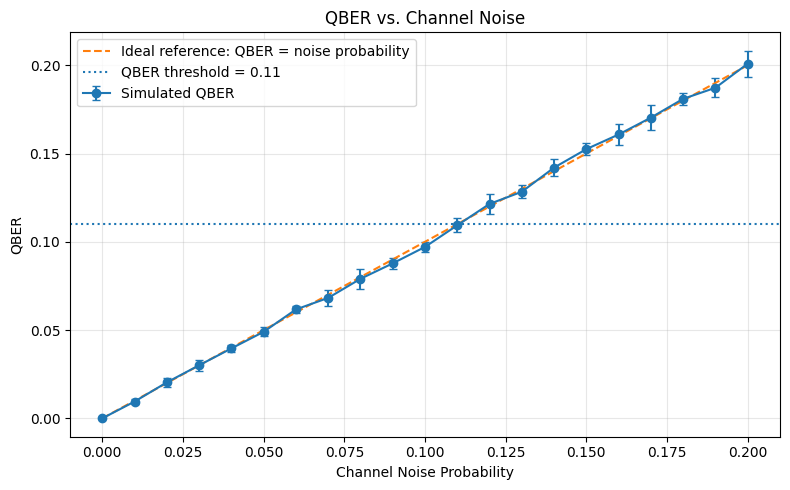

In [10]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    noise_results["noise_probability"],
    noise_results["qber_mean"],
    yerr=noise_results["qber_std"],
    marker="o",
    capsize=3,
    label="Simulated QBER",
)

plt.plot(
    noise_values,
    noise_values,
    linestyle="--",
    label="Ideal reference: QBER = noise probability",
)

plt.axhline(
    DEFAULT_QBER_THRESHOLD,
    linestyle=":",
    label=f"QBER threshold = {DEFAULT_QBER_THRESHOLD:.2f}",
)

plt.xlabel("Channel Noise Probability")
plt.ylabel("QBER")
plt.title("QBER vs. Channel Noise")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "results/qber_vs_noise.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 6.2 Estimated Secret-Key Rate vs. Channel Noise

We next examine how increasing QBER affects the estimated secret-key rate.

The secret-key rate is calculated using:

$$
R = q\,\max\left(0,1-2h_2(Q)\right)
$$

where $q$ is the sifted-key fraction and $Q$ is the measured QBER.

As noise increases, the binary entropy increases and the estimated secret-key fraction decreases.

Once the QBER becomes sufficiently large, the simplified model produces a zero secret-key rate.

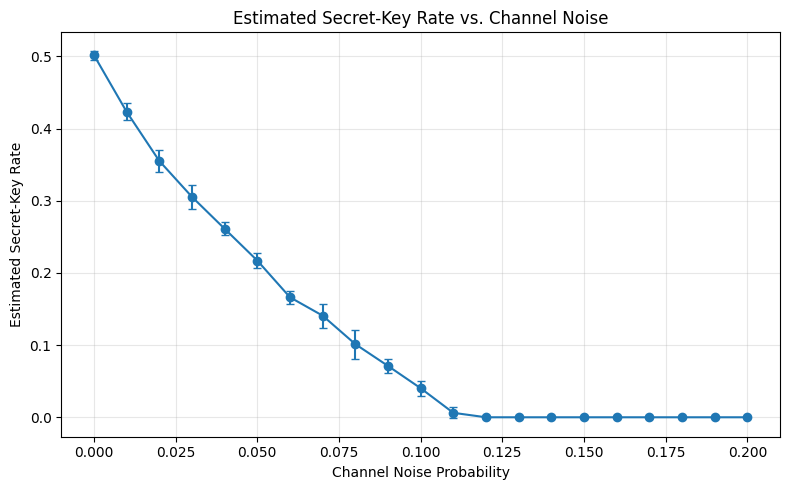

In [13]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    noise_results["noise_probability"],
    noise_results["secret_key_rate_mean"],
    yerr=noise_results["secret_key_rate_std"],
    marker="o",
    capsize=3,
)

plt.xlabel("Channel Noise Probability")
plt.ylabel("Estimated Secret-Key Rate")
plt.title("Estimated Secret-Key Rate vs. Channel Noise")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "results/key_rate_vs_noise.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 6.3 Detection and Sifted-Key Fraction

Channel noise changes the values of surviving bits but does not remove signals from the channel.

Therefore, the detection rate should remain approximately constant:

$$
D \approx 1
$$

Similarly, because there is no channel loss, the sifted-key fraction should remain close to the expected BB84 basis-matching probability of one half:

$$
q \approx 0.5
$$

This provides a useful consistency check that the simulator distinguishes channel noise from channel loss.

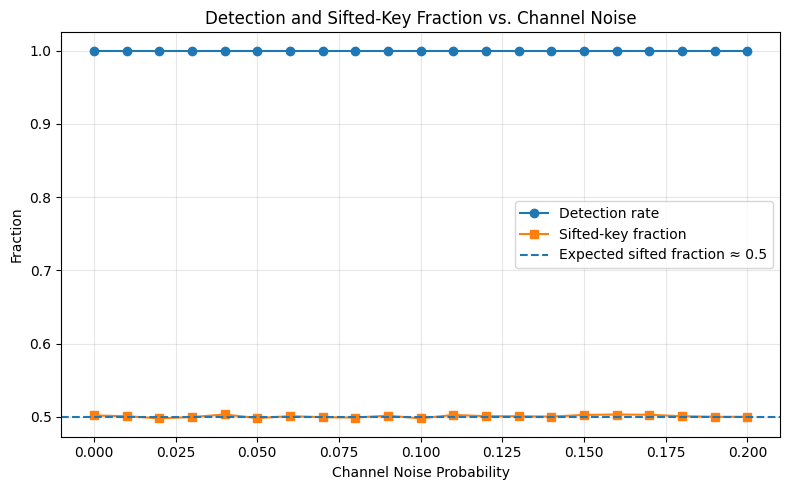

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    noise_results["noise_probability"],
    noise_results["detection_rate_mean"],
    marker="o",
    label="Detection rate",
)

plt.plot(
    noise_results["noise_probability"],
    noise_results["sifted_key_fraction_mean"],
    marker="s",
    label="Sifted-key fraction",
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Expected sifted fraction ≈ 0.5",
)

plt.xlabel("Channel Noise Probability")
plt.ylabel("Fraction")
plt.title("Detection and Sifted-Key Fraction vs. Channel Noise")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### 6.4 Interpretation

The noise experiment demonstrates the expected distinction between channel reliability and channel loss.

As the noise probability increases:

- QBER increases approximately with the applied noise probability.
- The detection rate remains approximately constant because no signals are intentionally removed.
- The sifted-key fraction remains approximately constant because basis selection is unaffected by channel noise.
- The estimated secret-key rate decreases as QBER increases.
- At sufficiently high QBER, the simplified asymptotic model estimates no usable secret key.

This experiment establishes the baseline relationship between channel noise and QKD performance before introducing eavesdropping or channel loss.

## 7. Experiment 2: Effect of Eve's Intercept-Resend Attack

The second experiment investigates how an intercept-resend eavesdropping attack affects the QKD link.

Eve's attack probability is varied while channel noise and channel loss are kept at zero:

$$
p_{\mathrm{noise}} = 0
$$

$$
p_{\mathrm{loss}} = 0
$$

The attack probability is varied over:

$$
p_{\mathrm{Eve}} \in [0,1]
$$

For each attack probability, multiple independent Monte Carlo trials are performed.

We measure:

- QBER
- Estimated secret-key rate
- Detection rate
- Sifted-key fraction

The main objective is to determine how increasing Eve's intervention affects the observable error rate and the estimated security of the generated key.

### 7.1 Attack Probability Sweep

The simulator is now evaluated for different probabilities of Eve intercepting and resending each transmitted state.

An attack probability of $0$ represents an attack-free channel, while an attack probability of $1$ means that Eve intercepts every transmitted state.

In [16]:
attack_values = np.linspace(0.0, 1.0, 21)

attack_results = run_attack_sweep(
    attack_values=attack_values,
    n_signals=N_SIGNALS,
    n_trials=N_TRIALS,
    noise_probability=0.0,
    loss_probability=0.0,
    seed=200,
)

attack_results.head()

,attack_probability,qber_mean,qber_std,secret_key_rate_mean,secret_key_rate_std,detection_rate_mean,sifted_key_fraction_mean
0,0.00,0.000000,0.000000,0.497910,0.006557,1.0,0.49791
1,0.05,0.012151,0.001100,0.406070,0.005354,1.0,0.50096
2,0.10,0.025988,0.001861,0.327674,0.010737,1.0,0.50219
3,0.15,0.035906,0.002371,0.276895,0.011782,1.0,0.49995
4,0.20,0.050285,0.003084,0.212715,0.014402,1.0,0.50030


In [17]:
attack_results

,attack_probability,qber_mean,qber_std,secret_key_rate_mean,secret_key_rate_std,detection_rate_mean,sifted_key_fraction_mean
0,0.00,0.000000,0.000000,0.497910,0.006557,1.0,0.49791
1,0.05,0.012151,0.001100,0.406070,0.005354,1.0,0.50096
2,0.10,0.025988,0.001861,0.327674,0.010737,1.0,0.50219
3,0.15,0.035906,0.002371,0.276895,0.011782,1.0,0.49995
4,0.20,0.050285,0.003084,0.212715,0.014402,1.0,0.50030
5,0.25,0.062785,0.004321,0.161969,0.016983,1.0,0.50047
6,0.30,0.075902,0.004292,0.113042,0.015841,1.0,0.50187
7,0.35,0.085474,0.002825,0.078997,0.009578,1.0,0.50082
8,0.40,0.098402,0.003803,0.036289,0.012098,1.0,0.50140
9,0.45,0.115148,0.004594,0.000794,0.002511,1.0,0.50005


### 7.2 QBER as a Function of Eve's Attack Probability

An intercept-resend attack introduces errors because Eve does not always measure the incoming state in the same basis used by Alice.

For a full intercept-resend attack, the ideal BB84 result is approximately:

$$
Q_{\mathrm{Eve}} \approx 0.25
$$

Therefore, when Eve attacks only a fraction of the transmitted states, the average QBER is expected to increase approximately with the attack probability:

$$
Q \approx 0.25\,p_{\mathrm{Eve}}
$$

The exact simulated result fluctuates around this relationship because the experiment uses finite Monte Carlo samples.

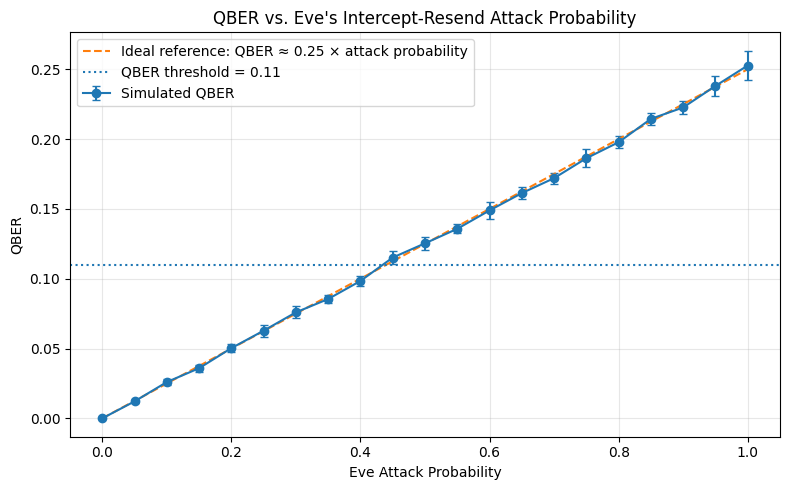

In [18]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    attack_results["attack_probability"],
    attack_results["qber_mean"],
    yerr=attack_results["qber_std"],
    marker="o",
    capsize=3,
    label="Simulated QBER",
)

plt.plot(
    attack_values,
    0.25 * attack_values,
    linestyle="--",
    label="Ideal reference: QBER ≈ 0.25 × attack probability",
)

plt.axhline(
    DEFAULT_QBER_THRESHOLD,
    linestyle=":",
    label=f"QBER threshold = {DEFAULT_QBER_THRESHOLD:.2f}",
)

plt.xlabel("Eve Attack Probability")
plt.ylabel("QBER")
plt.title("QBER vs. Eve's Intercept-Resend Attack Probability")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "results/qber_vs_attack.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 7.3 Estimated Secret-Key Rate vs. Eve's Attack Probability

The increase in QBER caused by Eve reduces the estimated secret-key fraction.

The estimated secret-key rate is:

$$
R =
q\max\left(0,1-2h_2(Q)\right)
$$

As the attack probability increases, the QBER increases and the estimated secret-key rate decreases.

Once the QBER exceeds the usable range of the simplified asymptotic model, the estimated secret-key rate becomes zero.

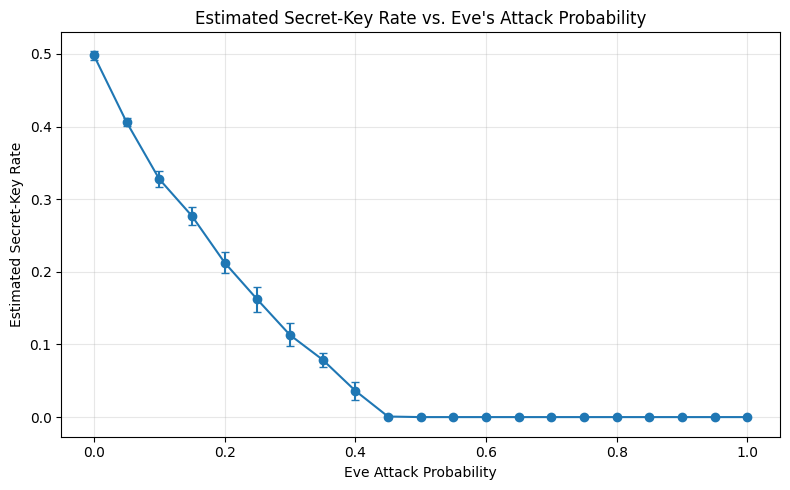

In [19]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    attack_results["attack_probability"],
    attack_results["secret_key_rate_mean"],
    yerr=attack_results["secret_key_rate_std"],
    marker="o",
    capsize=3,
)

plt.xlabel("Eve Attack Probability")
plt.ylabel("Estimated Secret-Key Rate")
plt.title("Estimated Secret-Key Rate vs. Eve's Attack Probability")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "results/key_rate_vs_attack.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 7.4 Detection and Sifted-Key Fraction

In this experiment, Eve does not intentionally remove signals and the physical channel has no loss.

Therefore, the detection rate should remain approximately:

$$
D \approx 1
$$

Similarly, the sifted-key fraction should remain close to:

$$
q \approx 0.5
$$

The main observable effect of Eve's intervention is therefore an increase in QBER rather than a reduction in the number of detected signals.

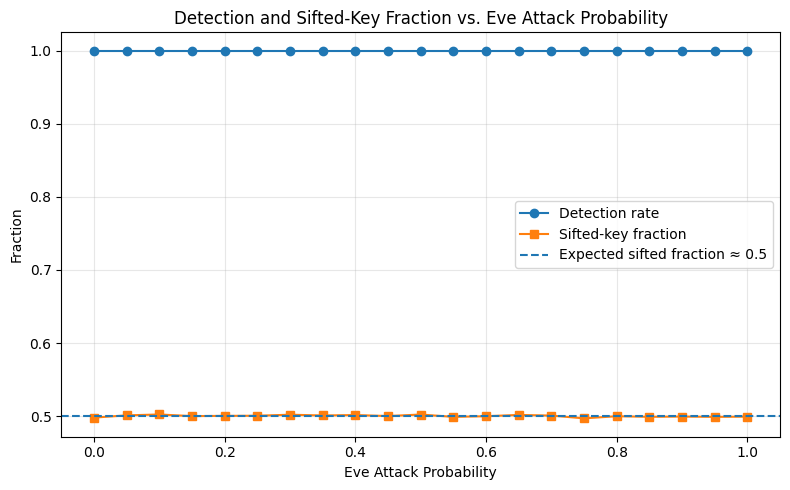

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    attack_results["attack_probability"],
    attack_results["detection_rate_mean"],
    marker="o",
    label="Detection rate",
)

plt.plot(
    attack_results["attack_probability"],
    attack_results["sifted_key_fraction_mean"],
    marker="s",
    label="Sifted-key fraction",
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Expected sifted fraction ≈ 0.5",
)

plt.xlabel("Eve Attack Probability")
plt.ylabel("Fraction")
plt.title("Detection and Sifted-Key Fraction vs. Eve Attack Probability")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### 7.5 Full Intercept-Resend Validation

For a complete intercept-resend attack:

$$
p_{\mathrm{Eve}} = 1
$$

BB84 predicts an error rate of approximately:

$$
Q \approx 0.25
$$

We can compare the simulated value directly with this theoretical expectation.

In [21]:
full_attack = simulate_bb84(
    n_signals=50_000,
    noise_probability=0.0,
    loss_probability=0.0,
    attack_probability=1.0,
    seed=250,
)

print(f"Simulated QBER: {full_attack['qber']:.4f}")
print("Expected QBER:  0.2500")
print(f"Difference:     {abs(full_attack['qber'] - 0.25):.4f}")

Simulated QBER: 0.2557
Expected QBER:  0.2500
Difference:     0.0057


The simulated QBER should fluctuate around the theoretical value of $0.25$ because the experiment uses a finite number of randomly generated signals.

Agreement between the simulation and the theoretical prediction provides a basic validation of the intercept-resend implementation.

### 7.6 Security Interpretation

The attack experiment illustrates an important property of BB84: eavesdropping can introduce errors that are statistically detectable by the communicating parties.

As Eve's attack probability increases:

- QBER increases.
- The estimated secret-key fraction decreases.
- The estimated secret-key rate eventually reaches zero.
- Detection rate remains approximately unchanged.
- The sifted-key fraction remains approximately unchanged.

For the simplified security interpretation used in this project, a QBER at or above the selected threshold is classified as:

**`abort`**

while a QBER below the threshold is classified as:

**`potentially_secure`**

The threshold used here is:

$$
Q_{\mathrm{threshold}} = 0.11
$$

This threshold is used as a simplified reference for the experiment and should not be interpreted as a universal security guarantee for all QKD implementations or finite-key systems.

### 7.7 Interpretation

The intercept-resend experiment demonstrates the relationship between eavesdropping and QKD observables.

A full intercept-resend attack produces approximately $25\%$ QBER, consistent with the expected BB84 behavior.

For partial attacks, the QBER increases approximately in proportion to the fraction of signals intercepted by Eve.

Unlike channel loss, the attack does not primarily reduce the number of detected signals. Instead, its main effect is to increase the disagreement between Alice's and Bob's sifted keys.

Consequently, QBER provides an observable indication that the communication channel may have been compromised or significantly disturbed.

The results also demonstrate why a QKD system does not simply need to establish a shared key: it must continuously evaluate the quality of the resulting key and determine whether the observed error rate is compatible with secure key generation.

## 8. Experiment 3: Effect of Channel Loss

The third experiment investigates how channel loss affects the performance of the QKD link.

The channel loss probability is varied while channel noise and Eve's attack probability are kept at zero:

$$
p_{\mathrm{noise}} = 0
$$

$$
p_{\mathrm{Eve}} = 0
$$

The loss probability is varied over:

$$
p_{\mathrm{loss}} \in [0,0.90]
$$

For each loss level, multiple independent Monte Carlo trials are performed.

We measure:

- Detection rate
- Sifted-key fraction
- QBER
- Estimated secret-key rate

Unlike channel noise, loss removes signals from the communication link rather than corrupting their encoded values.

The main objective is therefore to determine how increasing loss reduces the amount of usable key while leaving QBER approximately unchanged in this idealized model.

### 8.1 Loss Probability Sweep

The simulator is evaluated for different channel loss probabilities.

A loss probability of $0$ represents a channel in which every transmitted signal survives, while a loss probability of $1$ would remove every signal.

Because very high loss leaves relatively few detected signals, the experiment stops at $p_{\mathrm{loss}}=0.90$.

In [22]:
loss_values = np.linspace(0.0, 0.90, 19)

loss_results = run_loss_sweep(
    loss_values=loss_values,
    n_signals=N_SIGNALS,
    n_trials=N_TRIALS,
    noise_probability=0.0,
    attack_probability=0.0,
    seed=300,
)

loss_results.head()

,loss_probability,detection_rate_mean,detection_rate_std,sifted_key_fraction_mean,sifted_key_fraction_std,qber_mean,qber_std,secret_key_rate_mean,secret_key_rate_std
0,0.00,1.00000,0.000000,0.49994,0.005020,0.0,0.0,0.49994,0.005020
1,0.05,0.95068,0.002614,0.47697,0.006020,0.0,0.0,0.47697,0.006020
2,0.10,0.89884,0.003810,0.44898,0.006832,0.0,0.0,0.44898,0.006832
3,0.15,0.84770,0.003128,0.42023,0.004630,0.0,0.0,0.42023,0.004630
4,0.20,0.79879,0.002906,0.40150,0.005598,0.0,0.0,0.40150,0.005598


In [23]:
loss_results

,loss_probability,detection_rate_mean,detection_rate_std,sifted_key_fraction_mean,sifted_key_fraction_std,qber_mean,qber_std,secret_key_rate_mean,secret_key_rate_std
0,0.00,1.00000,0.000000,0.49994,0.005020,0.0,0.0,0.49994,0.005020
1,0.05,0.95068,0.002614,0.47697,0.006020,0.0,0.0,0.47697,0.006020
2,0.10,0.89884,0.003810,0.44898,0.006832,0.0,0.0,0.44898,0.006832
3,0.15,0.84770,0.003128,0.42023,0.004630,0.0,0.0,0.42023,0.004630
4,0.20,0.79879,0.002906,0.40150,0.005598,0.0,0.0,0.40150,0.005598
5,0.25,0.74771,0.004892,0.37394,0.005648,0.0,0.0,0.37394,0.005648
6,0.30,0.69685,0.003718,0.34846,0.004550,0.0,0.0,0.34846,0.004550
7,0.35,0.64763,0.003986,0.32306,0.004886,0.0,0.0,0.32306,0.004886
8,0.40,0.59872,0.005074,0.29833,0.005056,0.0,0.0,0.29833,0.005056
9,0.45,0.55149,0.005276,0.27711,0.003412,0.0,0.0,0.27711,0.003412


### 8.2 Detection Rate as a Function of Channel Loss

The detection rate is expected to decrease approximately linearly with channel loss.

The channel model defines the survival probability as:

$$
D = 1-p_{\mathrm{loss}}
$$

Therefore, increasing channel loss directly reduces the fraction of signals that reach Bob.

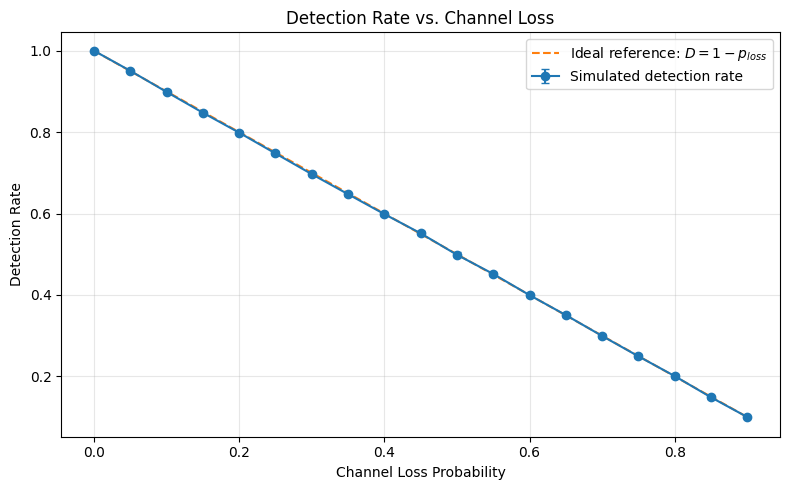

In [24]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    loss_results["loss_probability"],
    loss_results["detection_rate_mean"],
    yerr=loss_results["detection_rate_std"],
    marker="o",
    capsize=3,
    label="Simulated detection rate",
)

plt.plot(
    loss_values,
    1.0 - loss_values,
    linestyle="--",
    label="Ideal reference: $D = 1-p_{loss}$",
)

plt.xlabel("Channel Loss Probability")
plt.ylabel("Detection Rate")
plt.title("Detection Rate vs. Channel Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### 8.3 Sifted-Key Fraction as a Function of Channel Loss

The sifted-key fraction depends on both signal survival and basis matching.

With approximately half of the surviving signals expected to have matching bases:

$$
q \approx \frac{1}{2}(1-p_{\mathrm{loss}})
$$

Therefore, increasing channel loss should reduce the sifted-key fraction approximately linearly.

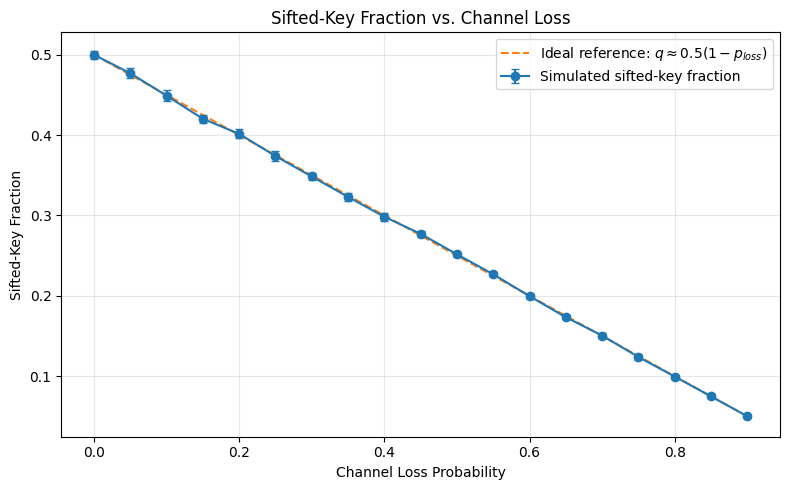

In [25]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    loss_results["loss_probability"],
    loss_results["sifted_key_fraction_mean"],
    yerr=loss_results["sifted_key_fraction_std"],
    marker="o",
    capsize=3,
    label="Simulated sifted-key fraction",
)

plt.plot(
    loss_values,
    0.5 * (1.0 - loss_values),
    linestyle="--",
    label="Ideal reference: $q \\approx 0.5(1-p_{loss})$",
)

plt.xlabel("Channel Loss Probability")
plt.ylabel("Sifted-Key Fraction")
plt.title("Sifted-Key Fraction vs. Channel Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### 8.4 QBER as a Function of Channel Loss

In the simplified model, channel loss removes signals but does not alter the bits of signals that survive.

Since no channel noise or eavesdropping is present, the QBER is therefore expected to remain approximately zero:

$$
Q \approx 0
$$

This illustrates the distinction between loss and bit errors:

- **Loss** reduces the number of usable signals.
- **Noise** changes the values of surviving signals.
- **Eavesdropping** can introduce detectable errors into surviving signals.

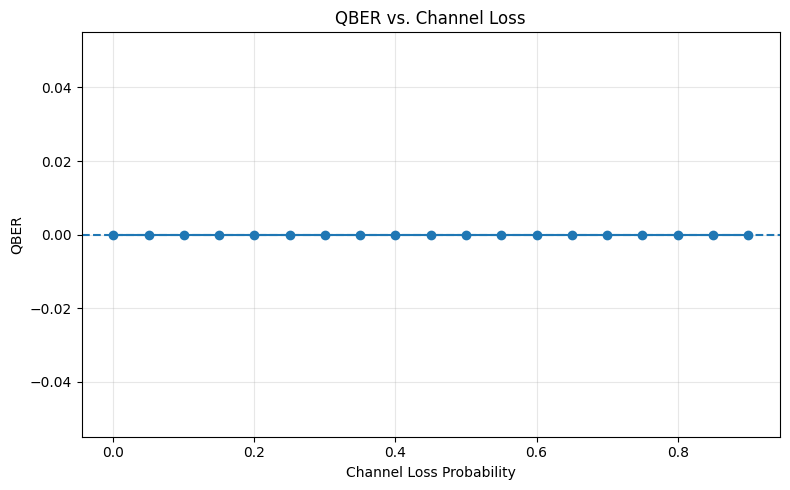

In [26]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    loss_results["loss_probability"],
    loss_results["qber_mean"],
    yerr=loss_results["qber_std"],
    marker="o",
    capsize=3,
)

plt.axhline(
    0.0,
    linestyle="--",
)

plt.xlabel("Channel Loss Probability")
plt.ylabel("QBER")
plt.title("QBER vs. Channel Loss")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### 8.5 Estimated Secret-Key Rate vs. Channel Loss

The estimated secret-key rate is:

$$
R = q\,r(Q)
$$

In this experiment, QBER remains approximately zero, so the secret-key fraction remains close to one.

Consequently, the main effect of channel loss is through the reduction of the sifted-key fraction:

$$
q \approx \frac{1}{2}(1-p_{\mathrm{loss}})
$$

The estimated secret-key rate should therefore decrease approximately with the surviving fraction of the channel.

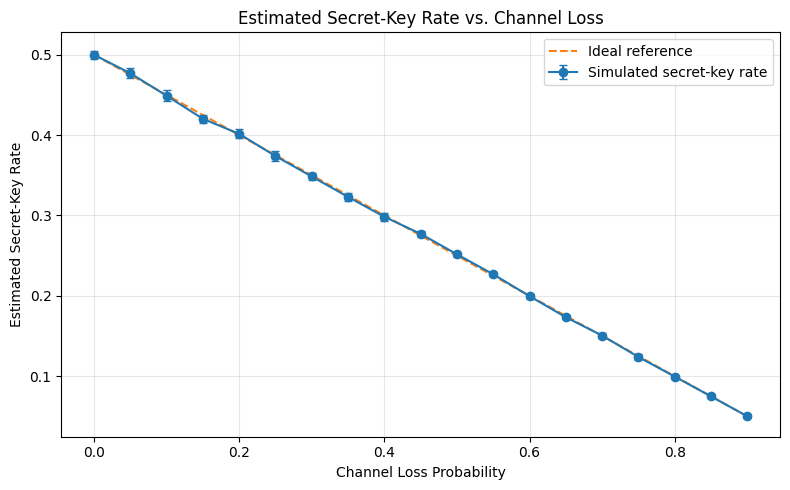

In [27]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    loss_results["loss_probability"],
    loss_results["secret_key_rate_mean"],
    yerr=loss_results["secret_key_rate_std"],
    marker="o",
    capsize=3,
    label="Simulated secret-key rate",
)

plt.plot(
    loss_values,
    0.5 * (1.0 - loss_values),
    linestyle="--",
    label="Ideal reference",
)

plt.xlabel("Channel Loss Probability")
plt.ylabel("Estimated Secret-Key Rate")
plt.title("Estimated Secret-Key Rate vs. Channel Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "results/loss_vs_key_rate.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 8.6 Interpretation

The loss experiment demonstrates a different failure mechanism from channel noise and eavesdropping.

As channel loss increases:

- Detection rate decreases.
- Sifted-key fraction decreases.
- Estimated secret-key rate decreases.
- QBER remains approximately zero in the absence of noise and eavesdropping.

This occurs because the simulator removes lost signals before Bob's measurement and basis sifting.

Therefore, loss primarily affects the **quantity of usable key**, whereas noise and eavesdropping primarily affect the **quality of the sifted key** through QBER.

This distinction is important when interpreting QKD link performance. A low QBER does not necessarily imply a high key-generation rate if the communication channel has substantial loss.

### 8.7 Distinguishing the Three Effects

The first three experiments reveal three different effects on the QKD link:

| Condition | Detection Rate | QBER | Secret-Key Rate |
|---|---|---|---|
| Channel noise | Approximately unchanged | Increases | Decreases |
| Eve's intercept-resend attack | Approximately unchanged | Increases | Decreases |
| Channel loss | Decreases | Approximately unchanged | Decreases |

The distinction can be summarized as:

$$
\text{Loss} \rightarrow \text{fewer usable signals}
$$

$$
\text{Noise} \rightarrow \text{more errors}
$$

$$
\text{Eavesdropping} \rightarrow \text{additional detectable errors}
$$

The next experiment combines noise and eavesdropping to investigate their joint effect on QBER and secret-key generation.

## 9. Experiment 4: Joint Effect of Channel Noise and Eve

The previous experiments varied one factor at a time. In this experiment, we study the combined effect of:

- Channel noise
- Eve's intercept-resend attack

Channel loss is kept at zero:

$$
p_{\mathrm{loss}} = 0
$$

We vary both parameters over a two-dimensional grid:

$$
p_{\mathrm{noise}} \in [0,0.20]
$$

$$
p_{\mathrm{Eve}} \in [0,1]
$$

For every combination of noise and attack probability, multiple Monte Carlo trials are performed.

The resulting QBER and estimated secret-key rate are visualized as two-dimensional heatmaps.

This experiment provides a more complete view of the operating conditions under which the simplified QKD model can generate an estimated secret key.

In [29]:
noise_grid = np.linspace(0.0, 0.20, 21)
attack_grid = np.linspace(0.0, 1.0, 21)

combined_results = run_noise_attack_sweep(
    noise_values=noise_grid,
    attack_values=attack_grid,
    n_signals=N_SIGNALS,
    n_trials=5,
    loss_probability=0.0,
    seed=400,
)

combined_results.head()

,noise_probability,attack_probability,qber_mean,qber_std,secret_key_rate_mean,secret_key_rate_std,detection_rate_mean,sifted_key_fraction_mean
0,0.0,0.00,0.000000,0.000000,0.498500,0.003652,1.0,0.49850
1,0.0,0.05,0.012399,0.001566,0.404015,0.011836,1.0,0.50022
2,0.0,0.10,0.023762,0.002695,0.335437,0.012190,1.0,0.49620
3,0.0,0.15,0.038151,0.003465,0.265157,0.018950,1.0,0.49734
4,0.0,0.20,0.050284,0.002494,0.213380,0.009640,1.0,0.50224


In [30]:
combined_results

,noise_probability,attack_probability,qber_mean,qber_std,secret_key_rate_mean,secret_key_rate_std,detection_rate_mean,sifted_key_fraction_mean
0,0.0,0.00,0.000000,0.000000,0.498500,0.003652,1.0,0.49850
1,0.0,0.05,0.012399,0.001566,0.404015,0.011836,1.0,0.50022
2,0.0,0.10,0.023762,0.002695,0.335437,0.012190,1.0,0.49620
3,0.0,0.15,0.038151,0.003465,0.265157,0.018950,1.0,0.49734
4,0.0,0.20,0.050284,0.002494,0.213380,0.009640,1.0,0.50224
...,...,...,...,...,...,...,...,...
436,0.2,0.80,0.317862,0.005562,0.000000,0.000000,1.0,0.50176
437,0.2,0.85,0.328746,0.010290,0.000000,0.000000,1.0,0.49934
438,0.2,0.90,0.337637,0.007719,0.000000,0.000000,1.0,0.50136
439,0.2,0.95,0.345049,0.007658,0.000000,0.000000,1.0,0.49950


### 9.2 QBER Across Noise and Eve Attack Conditions

The first heatmap shows how QBER changes when channel noise and Eve's attack probability are varied simultaneously.

Higher values of either parameter generally increase the observed QBER.

The dashed contour represents the simplified QBER threshold used in this project:

$$
Q_{\mathrm{threshold}} = 0.11
$$

Points above this boundary are classified as `abort` by the simplified security interpretation.

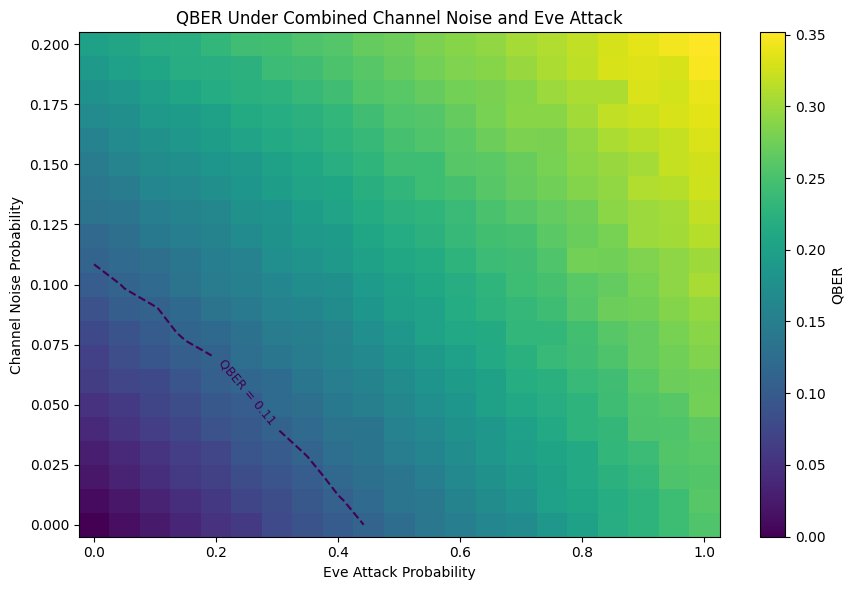

In [31]:
qber_matrix = combined_results.pivot(
    index="noise_probability",
    columns="attack_probability",
    values="qber_mean",
)

plt.figure(figsize=(9, 6))

mesh = plt.pcolormesh(
    qber_matrix.columns,
    qber_matrix.index,
    qber_matrix.values,
    shading="auto",
)

plt.colorbar(mesh, label="QBER")

CS = plt.contour(
    qber_matrix.columns,
    qber_matrix.index,
    qber_matrix.values,
    levels=[DEFAULT_QBER_THRESHOLD],
    linestyles="--",
)

plt.clabel(
    CS,
    inline=True,
    fontsize=9,
    fmt=f"QBER = {DEFAULT_QBER_THRESHOLD:.2f}",
)

plt.xlabel("Eve Attack Probability")
plt.ylabel("Channel Noise Probability")
plt.title("QBER Under Combined Channel Noise and Eve Attack")

plt.tight_layout()
plt.show()

### 9.3 Estimated Secret-Key Rate Across the Parameter Space

The second heatmap shows the estimated secret-key rate for the same combinations of channel noise and Eve attack probability.

The secret-key rate is calculated using:

$$
R = q\max\left(0,1-2h_2(Q)\right)
$$

Regions where the estimated rate approaches zero correspond to conditions where the simplified model cannot extract a secret key.

The result illustrates that QKD performance depends on the combined quality of the communication channel and the level of disturbance introduced by an adversary.

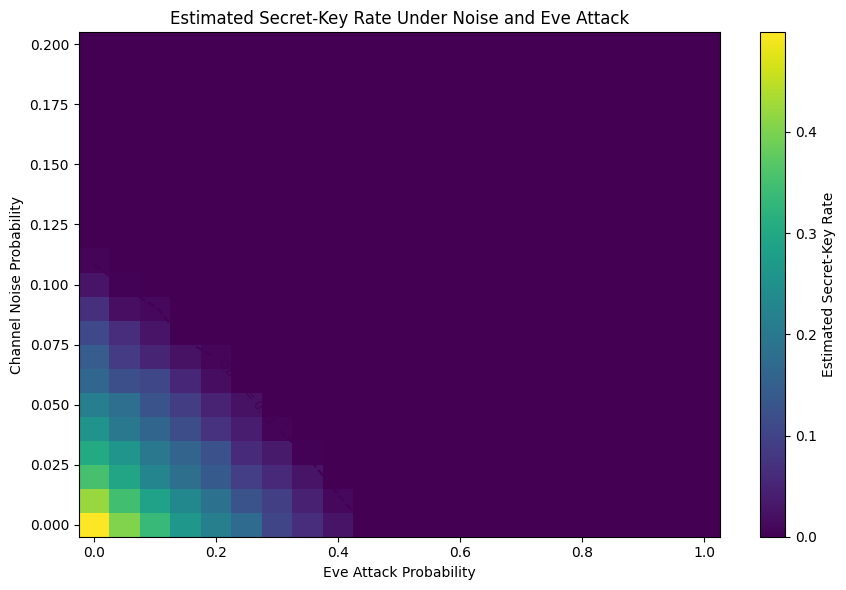

In [32]:
key_rate_matrix = combined_results.pivot(
    index="noise_probability",
    columns="attack_probability",
    values="secret_key_rate_mean",
)

qber_matrix = combined_results.pivot(
    index="noise_probability",
    columns="attack_probability",
    values="qber_mean",
)

plt.figure(figsize=(9, 6))

mesh = plt.pcolormesh(
    key_rate_matrix.columns,
    key_rate_matrix.index,
    key_rate_matrix.values,
    shading="auto",
)

plt.colorbar(mesh, label="Estimated Secret-Key Rate")

CS = plt.contour(
    qber_matrix.columns,
    qber_matrix.index,
    qber_matrix.values,
    levels=[DEFAULT_QBER_THRESHOLD],
    linestyles="--",
)

plt.clabel(
    CS,
    inline=True,
    fontsize=9,
    fmt=f"QBER = {DEFAULT_QBER_THRESHOLD:.2f}",
)

plt.xlabel("Eve Attack Probability")
plt.ylabel("Channel Noise Probability")
plt.title("Estimated Secret-Key Rate Under Noise and Eve Attack")

plt.tight_layout()

plt.savefig(
    "results/security_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 9.4 Interpretation

The two-dimensional experiment combines the effects observed in the previous experiments.

Increasing either channel noise or Eve's attack probability generally increases QBER and reduces the estimated secret-key rate.

The heatmap also shows that the two effects do not simply need to be considered independently. A QKD link that already experiences channel noise has less tolerance for additional disturbance caused by eavesdropping.

The region crossing the QBER threshold represents conditions where the simplified security interpretation changes from:

**`potentially_secure`**

to:

**`abort`**

This should be interpreted only within the assumptions of the simulator. The boundary is not a universal security boundary for real QKD systems.

Overall, the experiment demonstrates that QKD performance depends on both the physical quality of the communication channel and the disturbance introduced by potential eavesdropping.

## 10. Security Interpretation

The experiments demonstrate how different sources of channel impairment affect the observable behavior of a simplified BB84 link.

The simulator uses QBER as the primary indicator of whether the observed channel conditions are compatible with secret-key generation under the simplified model.

The selected threshold is:

$$
Q_{\mathrm{threshold}} = 0.11
$$

For the purposes of this project:

- If $Q < Q_{\mathrm{threshold}}$, the simulation classifies the condition as **potentially secure**.
- If $Q \geq Q_{\mathrm{threshold}}$, the simulation classifies the condition as **abort**.

This classification is an interpretation of the simplified asymptotic model used in the project. It should not be interpreted as a complete security proof.

### Why QBER Matters

QBER measures the disagreement between Alice's and Bob's sifted keys:

$$
Q =
\frac{N_{\mathrm{errors}}}
{N_{\mathrm{sifted}}}
$$

A low QBER means that Alice and Bob observe relatively few discrepancies in their sifted keys.

A high QBER indicates that the communication channel is significantly disturbed. Such disturbance may arise from channel noise, eavesdropping, or a combination of both.

### Role of Channel Loss

Channel loss has a different effect from QBER-producing mechanisms.

Loss reduces the number of signals available for key generation:

$$
q \approx \frac{1}{2}(1-p_{\mathrm{loss}})
$$

in the simplified model.

Therefore, a channel can have very low QBER while still producing a relatively small secret-key rate if its loss is high.

### Role of Noise and Eavesdropping

Channel noise and intercept-resend eavesdropping both increase the probability of disagreement between Alice's and Bob's sifted bits.

As QBER increases, the binary entropy increases:

$$
h_2(Q)
=
-Q\log_2(Q)
-(1-Q)\log_2(1-Q)
$$

and the estimated secret-key fraction decreases:

$$
r(Q)
=
\max\left(0,1-2h_2(Q)\right)
$$

Consequently, sufficiently high QBER causes the simplified model to estimate a zero secret-key rate.

### Interpretation of the Combined Heatmap

The noise-versus-Eve heatmap demonstrates that the operating conditions of a QKD link cannot be characterized by a single impairment in isolation.

A link that already experiences channel noise has less tolerance for additional disturbance from an intercept-resend attack.

The heatmap therefore provides a compact representation of the relationship between physical channel quality, adversarial disturbance, QBER, and estimated secret-key performance.

> **Important:** The security classification in this notebook is an educational and performance-oriented interpretation of the selected model. It is not a finite-key security analysis, composable security proof, or guarantee of security for a practical QKD implementation.

## 11. Key Findings

The simulations produce several consistent observations.

### 1. Channel Noise Increases QBER

Increasing the channel noise probability produces a corresponding increase in QBER.

Because the noise model independently flips surviving bits, the simulated QBER approximately follows the applied noise probability when no other impairment is present.

This demonstrates the direct relationship between channel errors and the quality of the sifted key.

### 2. Intercept-Resend Eavesdropping Produces Detectable Errors

Increasing Eve's attack probability increases QBER.

For a complete intercept-resend attack, the simulation approaches the expected BB84 result:

$$
Q \approx 0.25
$$

This provides a useful validation of the simplified eavesdropping model.

### 3. Channel Loss Reduces Key Availability

Increasing channel loss reduces the detection rate and the sifted-key fraction.

However, in the absence of noise and eavesdropping, it does not itself increase QBER.

This demonstrates that signal loss and signal errors represent different performance limitations.

### 4. Secret-Key Rate Depends on Both Signal Quantity and Quality

The estimated secret-key rate is:

$$
R = q\,r(Q)
$$

Therefore, both the number of usable signals and their error rate affect the final result.

A QKD link can therefore experience:

- low QBER but poor key generation because of high loss, or
- adequate signal detection but zero estimated key generation because QBER is too high.

### 5. Combined Impairments Reduce the Operating Margin

The two-dimensional noise-versus-Eve experiment demonstrates that channel noise and eavesdropping can jointly push the system toward the QBER threshold.

The resulting heatmap provides a compact view of the parameter region in which the simplified model estimates that secret-key generation remains possible.

Overall, the experiments demonstrate how a small probabilistic simulation can connect channel-level parameters to observable QKD performance metrics.

## 12. Limitations

This simulator intentionally focuses on a small and interpretable model of BB84. It should therefore not be interpreted as a complete QKD system simulator or security analysis framework.

### 12.1 Classical Probabilistic Representation

The BB84 states are represented using classical bit and basis variables rather than explicit quantum states or quantum circuits.

This is sufficient for reproducing the relevant BB84 measurement statistics used in these experiments, but it does not model the underlying quantum state vectors, density matrices, or optical fields.

### 12.2 Simplified Channel Model

Channel loss and noise are represented by independent probabilities.

A practical quantum communication channel can involve additional effects such as:

- distance-dependent attenuation
- atmospheric turbulence
- pointing and tracking errors
- detector inefficiency
- dark counts
- background photons
- polarization errors
- wavelength-dependent effects

These effects are outside the scope of the current model.

### 12.3 Simplified Eavesdropping Model

Only an intercept-resend attack is considered.

Real QKD security analysis must consider a much broader class of attacks and the assumptions under which the protocol remains secure.

The simulator does not attempt to model arbitrary or optimal quantum attacks.

### 12.4 Asymptotic Key-Rate Model

The secret-key rate uses the simplified expression:

$$
R =
q\max\left(0,1-2h_2(Q)\right)
$$

This is an asymptotic idealized model.

The simulator does not include:

- finite-key effects
- parameter-estimation uncertainty
- composable security bounds
- realistic error-correction leakage
- privacy-amplification implementation details

Therefore, the calculated rate should be interpreted as an estimated performance metric rather than a rigorous finite-key secret-key guarantee.

### 12.5 Statistical Sampling

The experiments use finite Monte Carlo samples.

Consequently, simulated measurements fluctuate around their expected values.

Increasing the number of transmitted signals or independent trials would reduce statistical uncertainty but would also increase computational cost.

### 12.6 No Physical Network Model

The simulator represents a single QKD communication link.

It does not model:

- multiple quantum nodes
- quantum memories
- quantum repeaters
- entanglement distribution
- network routing
- resource allocation
- network scheduling

These topics are relevant to larger quantum-network studies but are intentionally outside the scope of this project.

### Scope of the Project

The purpose of this project is therefore not to reproduce a production-grade QKD simulator.

Instead, it provides a compact computational model for studying the relationship between:

$$
\text{Channel Conditions}
\rightarrow
\text{QBER}
\rightarrow
\text{Secret-Key Performance}
$$

This provides a foundation for progressively more realistic physical and network-level models in future work.